In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models


In [37]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

# Turning the images in the CroppedImages directory into a dataset
imagePath="D:/SeniorProject/nbaImageDataset1.pt"
dataset = torch.load(imagePath, weights_only=False)

# Creating an 80/20 training/test split
trainSplit = int(.8 * len(dataset))
testSplit = len(dataset) - trainSplit
trainDataset, testDataset = torch.utils.data.random_split(dataset, [trainSplit, testSplit])
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Methods for Pretraining, Training, and Evaluation**

In [75]:
def evaluateModel(model, testLoader):

  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [ ]:
def pretrainModel(model, numEpochs = 20, batchSize = 256, learningRate = 0.001):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

    trainPath = "D:/SeniorProject/tiny-imagenet-200/train"
    valPath = "D:/SeniorProject/tiny-imagenet-200/val"

    trainDataset = ImageFolder(trainPath, transform=transform)
    valDataset = ImageFolder(valPath, transform=transform)

    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learningRate)
    criterion = nn.CrossEntropyLoss()

    bestWeights = model.state_dict()
    bestAccuracy = 0

    for epoch in range(numEpochs):
        print(f"Epoch {epoch + 1} / {numEpochs}")
        model.train()
        runningLoss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            runningLoss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Debugging information
            if i % 10 == 0:
                print(f"Batch {i}, Loss: {loss.item()}, Correct: {correct}, Total: {total}")


        trainLoss = runningLoss / len(trainLoader.dataset)
        trainAccuracy = correct / total
        print(f"Train Loss: {trainLoss:.4f}, Train Accuracy: {trainAccuracy:.4f}")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for data in valLoader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        valAccuracy = correct / total
        print(f"Validation Accuracy: {valAccuracy:.4f}")

        if valAccuracy > bestAccuracy:
            bestAccuracy = valAccuracy
            bestWeights = model.state_dict()
    
    print(f"Pretraining Complete.")
    model.load_state_dict(bestWeights)
    return model

In [78]:
def trainModel(model, numEpochs):
    transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

    # Turning the images in the CroppedImages directory into a dataset
    imagePath="D:/SeniorProject/nbaImageDataset1.pt"
    dataset = torch.load(imagePath, weights_only=False)

    # Creating an 80/20 training/test split
    trainSplit = int(.8 * len(dataset))
    testSplit = len(dataset) - trainSplit
    trainDataset, testDataset = torch.utils.data.random_split(dataset, [trainSplit, testSplit])
    trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
    testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")


    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

# **Custom Model**

In [82]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 30)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

**Baseline**

Epoch 1/15, Train Loss: 3.4035, Train Accuracy: 0.0418, Validation Loss: 3.3978, Validation Accuracy: 0.0238
Epoch 2/15, Train Loss: 3.3921, Train Accuracy: 0.0465, Validation Loss: 3.3952, Validation Accuracy: 0.0571
Epoch 3/15, Train Loss: 3.3769, Train Accuracy: 0.0621, Validation Loss: 3.3937, Validation Accuracy: 0.0524
Epoch 4/15, Train Loss: 3.3615, Train Accuracy: 0.0501, Validation Loss: 3.3755, Validation Accuracy: 0.0571
Epoch 5/15, Train Loss: 3.3358, Train Accuracy: 0.0847, Validation Loss: 3.3845, Validation Accuracy: 0.0619
Epoch 6/15, Train Loss: 3.2906, Train Accuracy: 0.1014, Validation Loss: 3.3888, Validation Accuracy: 0.0571
Epoch 7/15, Train Loss: 3.2352, Train Accuracy: 0.1217, Validation Loss: 3.3843, Validation Accuracy: 0.0619
Epoch 8/15, Train Loss: 3.1527, Train Accuracy: 0.1217, Validation Loss: 3.3761, Validation Accuracy: 0.0429
Epoch 9/15, Train Loss: 3.0397, Train Accuracy: 0.1527, Validation Loss: 3.3614, Validation Accuracy: 0.0619
Epoch 10/15, Train 

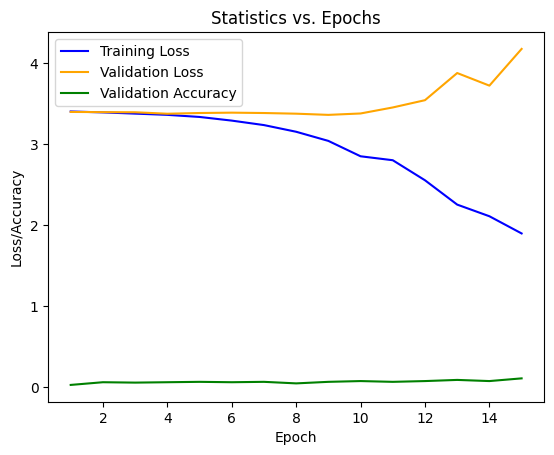

Accuracy: 50.0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 15)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/10, Train Loss: 3.3912, Train Accuracy: 0.0442, Validation Loss: 3.3735, Validation Accuracy: 0.0429
Epoch 2/10, Train Loss: 3.2295, Train Accuracy: 0.0835, Validation Loss: 3.3393, Validation Accuracy: 0.0762
Epoch 3/10, Train Loss: 2.8467, Train Accuracy: 0.1802, Validation Loss: 3.2805, Validation Accuracy: 0.0667
Epoch 4/10, Train Loss: 1.6379, Train Accuracy: 0.5895, Validation Loss: 4.1051, Validation Accuracy: 0.0714
Epoch 5/10, Train Loss: 0.3731, Train Accuracy: 0.9129, Validation Loss: 5.5165, Validation Accuracy: 0.1000
Epoch 6/10, Train Loss: 0.0860, Train Accuracy: 0.9893, Validation Loss: 6.2624, Validation Accuracy: 0.0810
Epoch 7/10, Train Loss: 0.0516, Train Accuracy: 0.9940, Validation Loss: 6.0728, Validation Accuracy: 0.0857
Epoch 8/10, Train Loss: 0.1394, Train Accuracy: 0.9952, Validation Loss: 6.2265, Validation Accuracy: 0.0714
Epoch 9/10, Train Loss: 0.0604, Train Accuracy: 0.9928, Validation Loss: 5.4485, Validation Accuracy: 0.1048
Epoch 10/10, Train 

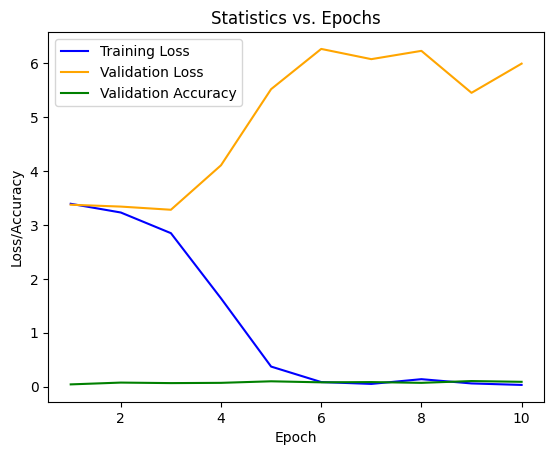

Accuracy: 79.04761904761905


In [84]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [ ]:
model = Net().to(device)
model = pretrainModel(model)

Epoch 1 / 20
Batch 0, Loss: 5.303183078765869, Correct: 0, Total: 256
Batch 10, Loss: 5.309586524963379, Correct: 15, Total: 2816
Batch 20, Loss: 5.300588607788086, Correct: 31, Total: 5376
Batch 30, Loss: 5.298951625823975, Correct: 34, Total: 7936
Batch 40, Loss: 5.253260135650635, Correct: 53, Total: 10496
Batch 50, Loss: 5.260446071624756, Correct: 82, Total: 13056
Batch 60, Loss: 5.237112998962402, Correct: 105, Total: 15616
Batch 70, Loss: 5.238299369812012, Correct: 141, Total: 18176
Batch 80, Loss: 5.138089179992676, Correct: 185, Total: 20736
Batch 90, Loss: 5.17416524887085, Correct: 227, Total: 23296
Batch 100, Loss: 5.0353617668151855, Correct: 288, Total: 25856
Batch 110, Loss: 4.980944633483887, Correct: 345, Total: 28416
Batch 120, Loss: 4.930058002471924, Correct: 407, Total: 30976
Batch 130, Loss: 4.848883628845215, Correct: 487, Total: 33536
Batch 140, Loss: 4.802542686462402, Correct: 574, Total: 36096
Batch 150, Loss: 4.955142498016357, Correct: 675, Total: 38656
Ba

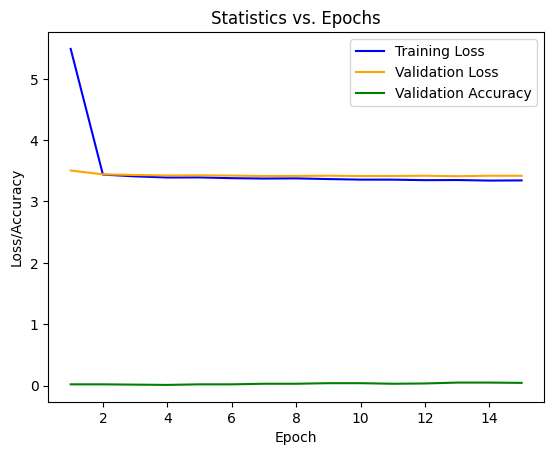

Accuracy: 9.523809523809524%


In [12]:
model.fc3 = nn.Linear(84, 30)
model.to(device)
model = trainModel(model, 15)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}%")

In [105]:
class LeNet5(nn.Module):
        def __init__(self, num_classes):
            super(LeNet5, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0),
                nn.BatchNorm2d(6),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(6, 16, kernel_size=5, stride=3, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.fc = nn.Linear(16 * 18 * 18, 120)
            self.relu = nn.ReLU()
            self.fc1 = nn.Linear(120, 84)
            self.relu1 = nn.ReLU()
            self.fc2 = nn.Linear(84, num_classes)
            
        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.relu(out)
            out = self.fc1(out)
            out = self.relu1(out)
            out = self.fc2(out)
            return out

Epoch 1/20, Train Loss: 3.4246, Train Accuracy: 0.0465, Validation Loss: 3.3474, Validation Accuracy: 0.0333
Epoch 2/20, Train Loss: 3.1911, Train Accuracy: 0.0979, Validation Loss: 3.1915, Validation Accuracy: 0.0905
Epoch 3/20, Train Loss: 2.9650, Train Accuracy: 0.1408, Validation Loss: 3.0863, Validation Accuracy: 0.1095
Epoch 4/20, Train Loss: 2.7373, Train Accuracy: 0.2124, Validation Loss: 3.0573, Validation Accuracy: 0.0857
Epoch 5/20, Train Loss: 2.5036, Train Accuracy: 0.2780, Validation Loss: 3.0997, Validation Accuracy: 0.1048
Epoch 6/20, Train Loss: 2.1060, Train Accuracy: 0.4081, Validation Loss: 3.1938, Validation Accuracy: 0.1048
Epoch 7/20, Train Loss: 1.6946, Train Accuracy: 0.5095, Validation Loss: 3.4048, Validation Accuracy: 0.1286
Epoch 8/20, Train Loss: 1.3299, Train Accuracy: 0.6575, Validation Loss: 3.6971, Validation Accuracy: 0.1000
Epoch 9/20, Train Loss: 0.8560, Train Accuracy: 0.8007, Validation Loss: 3.7431, Validation Accuracy: 0.1238
Epoch 10/20, Train 

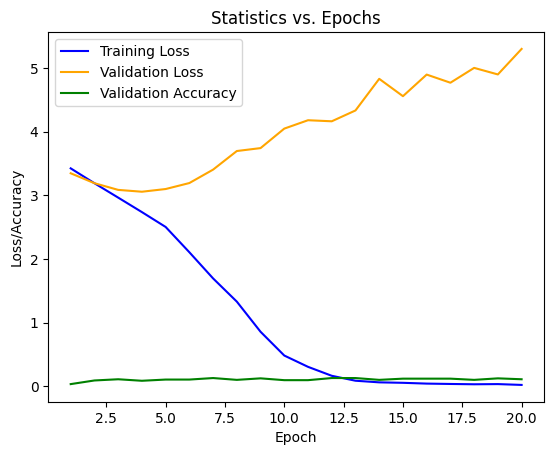

Accuracy: 83.3333%


In [108]:
model = LeNet5(30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

In [ ]:
model = models.resnet18()
model.fc = nn.Linear(512, 30)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = trainModel(model, 10)
print(f"Accuracy: {evaluateModel(model, testLoader):.4f}%")